C:\Users\Gaurang\AppData\Local\Temp\ipykernel_19508\408987836.py:16: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'])


Running GARCH Grid Search...

GARCH(1,0,1) → QLIKE: 0.0498
GARCH(1,0,2) → QLIKE: 0.0498
GARCH(1,1,1) → QLIKE: 0.0966
GARCH(1,1,2) → QLIKE: 0.0966
GARCH(2,0,1) → QLIKE: 0.0644
GARCH(2,0,2) → QLIKE: 0.0630
GARCH(2,1,1) → QLIKE: 0.0876
GARCH(2,1,2) → QLIKE: 0.0876

Best Parameters: (1, 0, 1)
Best QLIKE: 0.049778878249481705
677 677
Volatility Model Performance:


MSE: 0.19201081030891815
RMSE: 0.4381903813514374
QLIKE: 0.20473706943172645


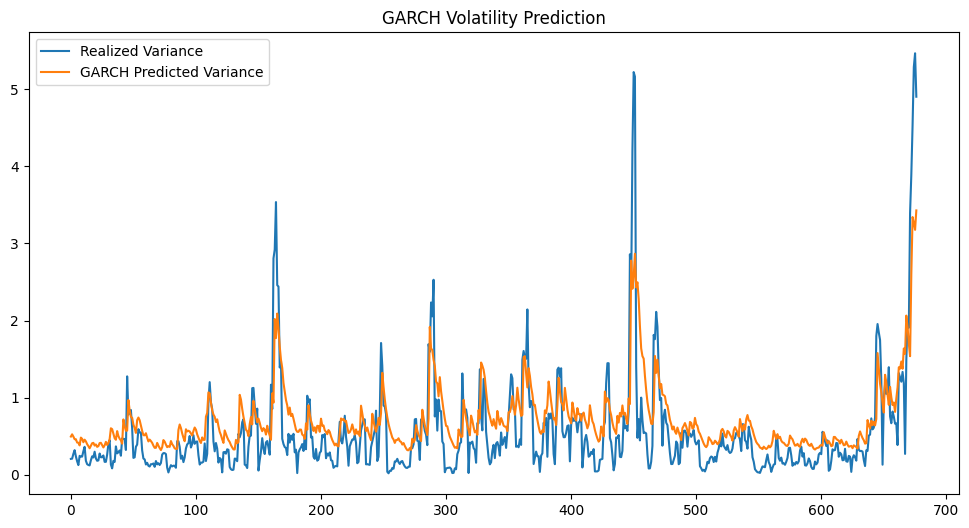

: 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from scipy.stats import zscore

from arch import arch_model


# -------------------------------
# 🔹 Load Data
# -------------------------------
df = pd.read_csv("D:\\COLLEGE\\DAIICT\\Semester-2\\Applied Forecasting\\re_implemented_project\\data\\nifty50_with_sector_returns_yfinance1.csv")

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
df.set_index('date', inplace=True)

df = df[~df.index.duplicated()]
df = df.ffill().bfill()

df = df[(np.abs(zscore(df)) < 3).all(axis=1)]


# -------------------------------
# 🔹 Return Calculation
# -------------------------------
df['return'] = df['close'].pct_change()
df = df.dropna()

returns = df['return'] * 100

# Realized variance
realized_var = (returns.rolling(5).std())**2

# Align both series
data = pd.concat([returns, realized_var], axis=1)
data.columns = ['returns', 'realized_var']
data = data.dropna()

# Extract aligned series
returns = data['returns']
realized_var = data['realized_var']

# Now split (AFTER alignment)
split = int(0.8 * len(data))

train_ret = returns[:split]
test_ret = returns[split:]

train_var = realized_var[:split]
test_var = realized_var[split:]
train_ret, test_ret = returns[:split], returns[split:]
train_var, test_var = realized_var[:split], realized_var[split:]


# -------------------------------
# 🔹 Hyperparameter Grid Search
# -------------------------------
import itertools

param_grid = {
    "p": [1, 2],
    "o": [0, 1],   # asymmetry term (GJR)
    "q": [1, 2]
}

def qlike_loss(y_true, y_pred):
    return np.mean(np.log(y_pred) + (y_true / y_pred))


best_score = float("inf")
best_params = None

print("Running GARCH Grid Search...\n")

for p, o, q in itertools.product(param_grid["p"], param_grid["o"], param_grid["q"]):

    try:
        pred_var_temp = []
        true_var_temp = []

        # small subset for faster tuning (important ⚡)
        tuning_size = int(0.3 * len(test_var))

        for i in range(tuning_size):

            train_subset = returns[:split + i]

            model = arch_model(train_subset, vol='GARCH', p=p, o=o, q=q)
            res = model.fit(disp='off')

            forecast = res.forecast(horizon=1)

            sigma2 = forecast.variance.iloc[-1, 0]

            pred_var_temp.append(sigma2)
            true_var_temp.append(test_var.iloc[i])

        pred_var_temp = np.array(pred_var_temp)
        true_var_temp = np.array(true_var_temp)

        score = qlike_loss(true_var_temp, pred_var_temp)

        print(f"GARCH({p},{o},{q}) → QLIKE: {score:.4f}")

        if score < best_score:
            best_score = score
            best_params = (p, o, q)

    except:
        continue


print("\nBest Parameters:", best_params)
print("Best QLIKE:", best_score)

# -------------------------------
# 🔹 Rolling GARCH Forecast
# -------------------------------
pred_var = []
true_var = []

print(len(test_ret), len(test_var))
for i in range(len(test_ret)):

    train_subset = returns[:split + i]

    # model = arch_model(train_subset, vol='GARCH', p=1, o=1, q=1)

    p_best, o_best, q_best = best_params

    model = arch_model(train_subset, vol='GARCH', p=p_best, o=o_best, q=q_best)
    res = model.fit(disp='off')

    forecast = res.forecast(horizon=1)

    # Predicted variance
    sigma2 = forecast.variance.iloc[-1, 0]

    pred_var.append(sigma2)
    true_var.append(test_var.iloc[i])

pred_var = np.array(pred_var)
true_var = np.array(true_var)


# -------------------------------
# 🔹 Evaluation Metrics
# -------------------------------

def evaluate_volatility(y_true, y_pred):

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    qlike = np.mean(np.log(y_pred) + (y_true / y_pred))

    print("Volatility Model Performance:")
    print("\n")
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("QLIKE:", qlike)

evaluate_volatility(true_var, pred_var)


# -------------------------------
# 🔹 Visualization
# -------------------------------

plt.figure(figsize=(12,6))
plt.plot(true_var, label="Realized Variance")
plt.plot(pred_var, label="GARCH Predicted Variance")
plt.title("GARCH Volatility Prediction")
plt.legend()
plt.show()


